# 4. Chargement des données

In [4]:
import pandas as pd

movies = pd.read_csv("../data/row/movies.csv")
ratings = pd.read_csv("../data/row/ratings.csv")

# 4.1 Structure et dimensions des données

In [5]:
print("Movies :", movies.shape)
print("Ratings :", ratings.shape)

# Dimensions du dataset movies et ratings
print("Dimensions du dataset movies :", movies.shape)
print("Dimensions du dataset ratings :", ratings.shape)

Movies : (27278, 3)
Ratings : (20000263, 4)
Dimensions du dataset movies : (27278, 3)
Dimensions du dataset ratings : (20000263, 4)


# 4.2 Types des variables


In [6]:
# Types des variables dans movies et ratings
print("Types des variables dans movies :")
print(movies.dtypes)
print("\nTypes des variables dans ratings :")
print(ratings.dtypes)
movies.info()
ratings.info()

Types des variables dans movies :
movieId    int64
title        str
genres       str
dtype: object

Types des variables dans ratings :
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
dtypes: int64(1), str(2)
memory usage: 639.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 610.4 MB


# 4.3 Statistiques descriptives


In [7]:
# première vue d’ensemble des variables numériques du dataset ratings
ratings.describe()

,userId,movieId,rating,timestamp
count,2.000026e+07,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00,1.100918e+09
std,4.003863e+04,1.978948e+04,1.051989e+00,1.621694e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,3.439500e+04,9.020000e+02,3.000000e+00,9.667977e+08
50%,6.914100e+04,2.167000e+03,3.500000e+00,1.103556e+09
75%,1.036370e+05,4.770000e+03,4.000000e+00,1.225642e+09
max,1.384930e+05,1.312620e+05,5.000000e+00,1.427784e+09


# 4.4 Valeurs manquantes


In [8]:
# Valeurs manquantes movies
print("Valeurs manquantes dans movies :")
print(movies.isnull().sum())

# Valeurs manquantes ratings
print("\nValeurs manquantes dans ratings :")
print(ratings.isnull().sum())

Valeurs manquantes dans movies :
movieId    0
title      0
genres     0
dtype: int64

Valeurs manquantes dans ratings :
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


# 4.5 Doublons et incohérences


In [9]:
# Vérification Doublons
print("Nombre de doublons dans movies :", movies.duplicated().sum())
print("Nombre de doublons dans ratings :", ratings.duplicated().sum())


# Vérification des incohérences
print("Note minimale :", ratings["rating"].min())
print("Note maximale :", ratings["rating"].max())

invalid_ratings = ratings[
    (ratings["rating"] < 0.5) | (ratings["rating"] > 5)
]

print("Nombre de notes incohérentes :", len(invalid_ratings))

missing_movies = ratings[
    ~ratings["movieId"].isin(movies["movieId"])
]

print("Nombre de movieId absents dans movies :", len(missing_movies))


Nombre de doublons dans movies : 0
Nombre de doublons dans ratings : 0
Note minimale : 0.5
Note maximale : 5.0
Nombre de notes incohérentes : 0
Nombre de movieId absents dans movies : 0


# 5. Analyse des données


# 5.1 Analyse des utilisateurs


# 5.1.1 Nombre d’utilisateurs

In [10]:
print("Nombre total d'utilisateurs :", ratings["userId"].nunique())

Nombre total d'utilisateurs : 138493


# 5.1.2 Nombre d’évaluations par utilisateur

In [11]:
# Nombre de ratings par utilisateur
user_ratings = ratings.groupby("userId").size()
print(user_ratings.head())

# Statistiques descriptives :

print("Nombre moyen de ratings par utilisateur :", user_ratings.mean())
print("Nombre médian de ratings par utilisateur :", user_ratings.median())
print("Nombre minimum de ratings :", user_ratings.min())
print("Nombre maximum de ratings :", user_ratings.max())

userId
1    175
2     61
3    187
4     28
5     66
dtype: int64
Nombre moyen de ratings par utilisateur : 144.4135299257002
Nombre médian de ratings par utilisateur : 68.0
Nombre minimum de ratings : 20
Nombre maximum de ratings : 9254


# 5.1.3 Utilisateurs les plus actifs

In [12]:
top_users = user_ratings.sort_values( ascending=False ).head(10)
print(top_users)

userId
118205    9254
8405      7515
82418     5646
121535    5520
125794    5491
74142     5447
34576     5356
131904    5330
83090     5169
59477     4988
dtype: int64


# 5.1.4 Distribution de l’activité des utilisateurs

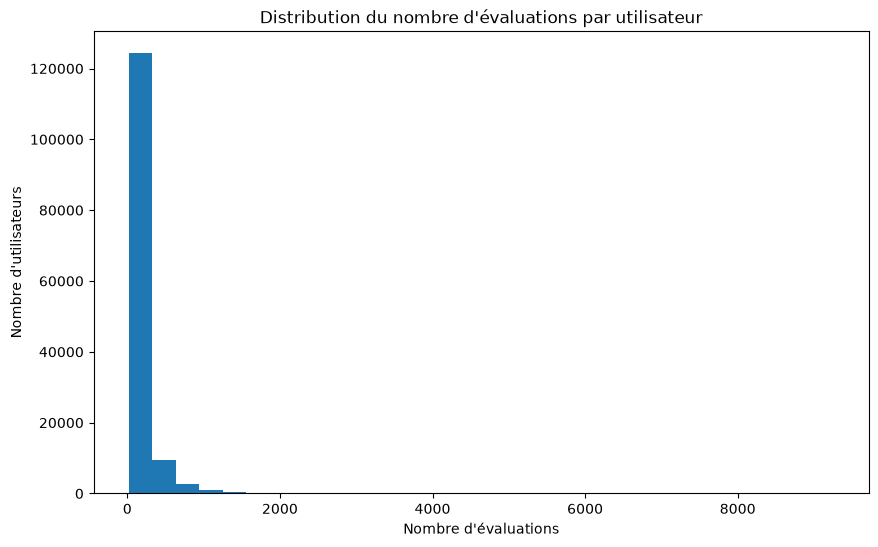

In [13]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(10, 6)) 
plt.hist( user_ratings, bins=30 )
plt.title("Distribution du nombre d'évaluations par utilisateur")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Nombre d'utilisateurs")
plt.show()

# 5.2 Analyse des films

# 5.2.1 Nombre total de films

In [14]:
# Nombre total de films dans le dataset
nb_movies = movies["movieId"].nunique()

# Nombre de films ayant reçu au moins une évaluation
nb_movies_rated = ratings["movieId"].nunique()

print("Nombre total de films :", nb_movies)
print("Nombre de films évalués :", nb_movies_rated)

Nombre total de films : 27278
Nombre de films évalués : 26744


# 5.2.2 Nombre d’évaluations par film

In [15]:
# Nombre d'évaluations par film
movie_ratings = ratings.groupby("movieId").size()

print("Nombre moyen d'évaluations par film :", movie_ratings.mean())
print("Nombre médian d'évaluations par film :", movie_ratings.median())
print("Nombre minimum d'évaluations :", movie_ratings.min())
print("Nombre maximum d'évaluations :", movie_ratings.max())

Nombre moyen d'évaluations par film : 747.8411232425965
Nombre médian d'évaluations par film : 18.0
Nombre minimum d'évaluations : 1
Nombre maximum d'évaluations : 67310


# 5.2.3 Films les plus évalués

In [16]:
# Nombre d'évaluations par film
movie_ratings = ratings.groupby("movieId").size()

# Top 10 des films les plus évalués
top_movies = movie_ratings.sort_values(
    ascending=False
).head(10)

# Ajouter le titre des films
top_movies_df = top_movies.reset_index(
    name="rating_count"
).merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
).sort_values(
    "rating_count",
    ascending=False
)

print(top_movies_df[["movieId", "title", "rating_count"]])

   movieId                                      title  rating_count
0      296                        Pulp Fiction (1994)         67310
1      356                        Forrest Gump (1994)         66172
2      318           Shawshank Redemption, The (1994)         63366
3      593           Silence of the Lambs, The (1991)         63299
4      480                       Jurassic Park (1993)         59715
5      260  Star Wars: Episode IV - A New Hope (1977)         54502
6      110                          Braveheart (1995)         53769
7      589          Terminator 2: Judgment Day (1991)         52244
8     2571                         Matrix, The (1999)         51334
9      527                    Schindler's List (1993)         50054


# 5.2.4 Note moyenne des films

In [17]:
# Calcul des statistiques pour chaque film
movie_stats = ratings.groupby("movieId").agg(
    rating_count=("rating", "count"),
    rating_mean=("rating", "mean")
)

print("Note moyenne globale des films :", movie_stats["rating_mean"].mean())
print("Note minimale :", movie_stats["rating_mean"].min())
print("Note maximale :", movie_stats["rating_mean"].max())

Note moyenne globale des films : 3.133199990125693
Note minimale : 0.5
Note maximale : 5.0


# 5.2.5 Films les mieux notés


In [18]:
# Calcul des statistiques pour chaque film
movie_stats = ratings.groupby("movieId").agg(
    rating_count=("rating", "count"),
    rating_mean=("rating", "mean")
).reset_index()

# Garder uniquement les films ayant au moins 100 évaluations
top_rated = movie_stats[
    movie_stats["rating_count"] >= 100
].sort_values(
    "rating_mean",
    ascending=False
).head(10)

# Ajouter les titres des films
top_rated = top_rated.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

print(
    top_rated[
        ["movieId", "title", "rating_count", "rating_mean"]
    ]
)

   movieId                                          title  rating_count  \
0      318               Shawshank Redemption, The (1994)         63366   
1      858                          Godfather, The (1972)         41355   
2       50                     Usual Suspects, The (1995)         47006   
3      527                        Schindler's List (1993)         50054   
4     1221                 Godfather: Part II, The (1974)         27398   
5     2019    Seven Samurai (Shichinin no samurai) (1954)         11611   
6      904                             Rear Window (1954)         17449   
7     7502                        Band of Brothers (2001)          4305   
8      912                              Casablanca (1942)         24349   
9      922  Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)          6525   

   rating_mean  
0     4.446990  
1     4.364732  
2     4.334372  
3     4.310175  
4     4.275641  
5     4.274180  
6     4.271334  
7     4.263182  
8     4.258327  
9   

# 5.2.6 Relation entre le nombre d’évaluations et la note moyenne


In [19]:
# Calcul des statistiques pour chaque film
movie_stats = ratings.groupby("movieId").agg(
    rating_count=("rating", "count"),
    rating_mean=("rating", "mean")
).reset_index()

# Corrélation entre popularité et note moyenne
correlation = movie_stats["rating_count"].corr(
    movie_stats["rating_mean"]
)

print("Corrélation entre le nombre d'évaluations et la note moyenne :", correlation)

Corrélation entre le nombre d'évaluations et la note moyenne : 0.1431798756164809


# 5.3 Analyse des évaluations


# 5.4 Analyse des genres
